in this part i will try my best to make clasification model

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
# Generate spiral data
def make_spirals(n_samples=1000, n_classes=3, noise=0.1, random_state=42):
    np.random.seed(random_state)
    X = []
    y = []
    n_per_class = n_samples // n_classes
    for c in range(n_classes):
        t = np.linspace(0, 4 * np.pi, n_per_class)
        r = t / (4 * np.pi)
        angle = t + (2 * np.pi * c / n_classes)
        x1 = r * np.cos(angle) + np.random.randn(n_per_class) * noise
        x2 = r * np.sin(angle) + np.random.randn(n_per_class) * noise
        X.append(np.stack([x1, x2], axis=1))
        y.append(np.full(n_per_class, c))
    return np.vstack(X), np.concatenate(y)

X, y = make_spirals(n_samples=1000, n_classes=3, noise=0.05)
X[:5],y[:5]

(array([[ 0.02483571, -0.03385809],
        [-0.00390332,  0.04886997],
        [ 0.03839127, -0.00689727],
        [ 0.08512944, -0.040251  ],
        [ 0.0002027 , -0.01425213]]),
 array([0, 0, 0, 0, 0]))

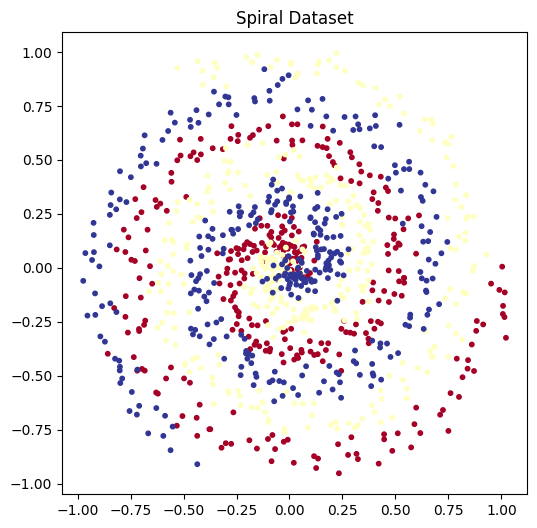

In [3]:


# Visualize
plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10)
plt.title("Spiral Dataset")
plt.show()

In [5]:
x=torch.tensor(X)
y=torch.tensor(y)
x[:5],y[:5]

(tensor([[ 0.0248, -0.0339],
         [-0.0039,  0.0489],
         [ 0.0384, -0.0069],
         [ 0.0851, -0.0403],
         [ 0.0002, -0.0143]], dtype=torch.float64),
 tensor([0, 0, 0, 0, 0]))

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


(tensor([[-0.1632,  0.2814],
         [-0.1536, -0.8378],
         [ 0.5173, -0.0626],
         [-0.8410,  0.3488],
         [-0.0618,  0.4447]], dtype=torch.float64),
 tensor([2, 0, 0, 2, 1]))

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)
x_train[:5],y_train[:5]

(tensor([[-0.1632,  0.2814],
         [-0.1536, -0.8378],
         [ 0.5173, -0.0626],
         [-0.8410,  0.3488],
         [-0.0618,  0.4447]], device='cuda:0', dtype=torch.float64),
 tensor([2, 0, 0, 2, 1], device='cuda:0'))